In [36]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit
import joblib

In [37]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
cols = df.columns

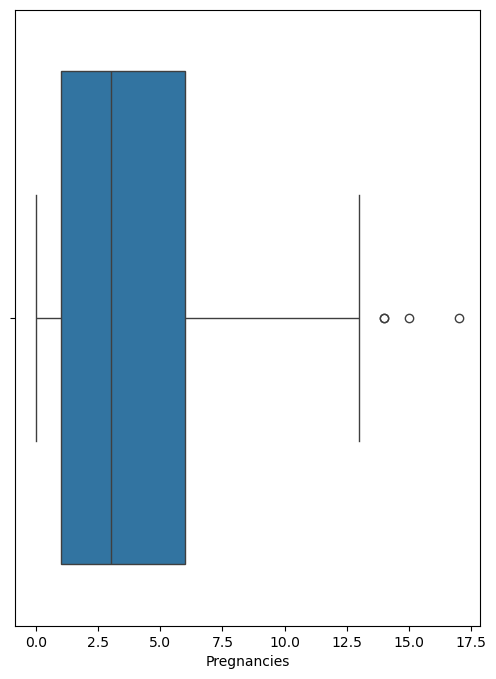

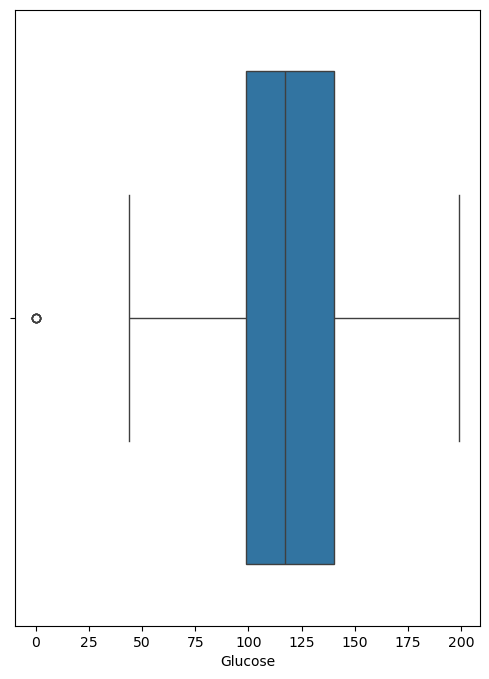

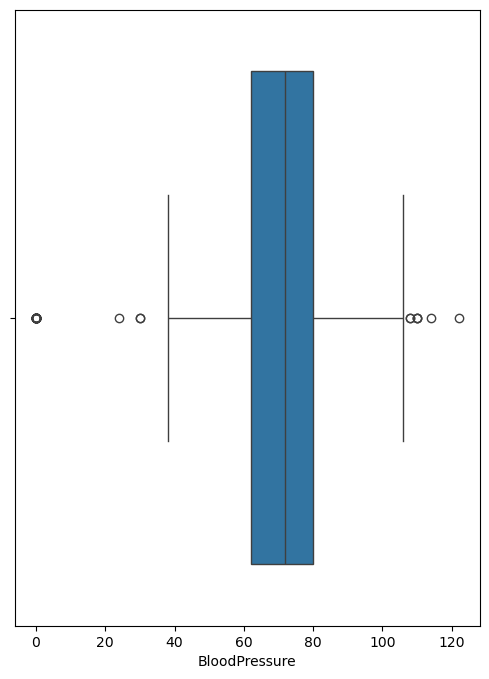

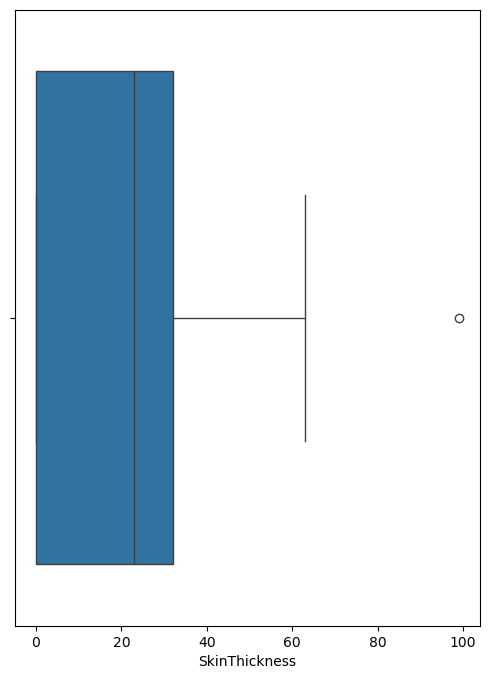

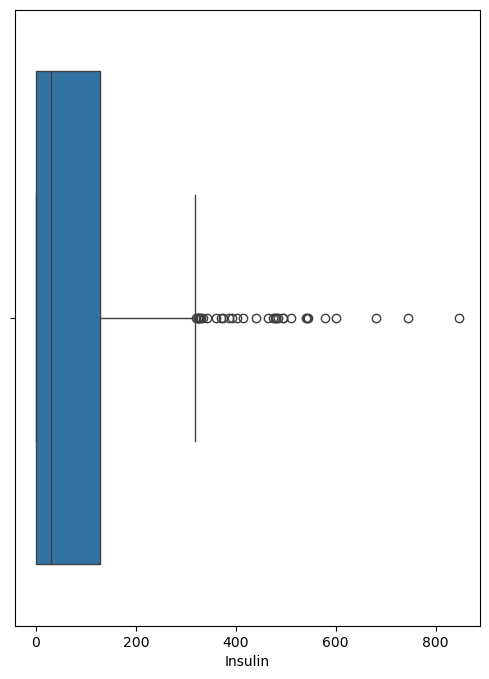

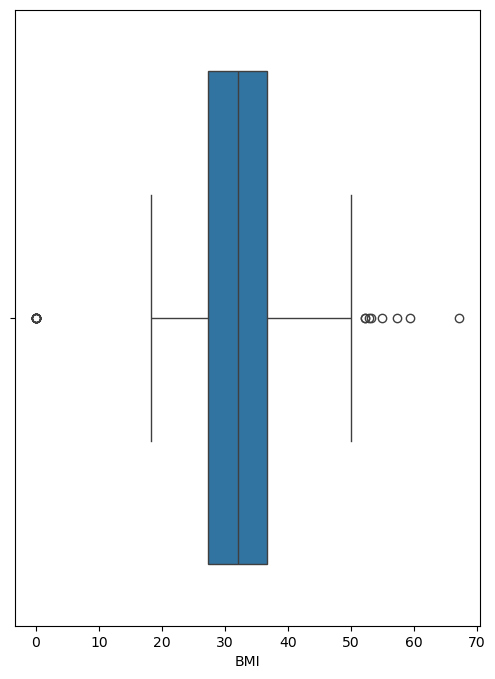

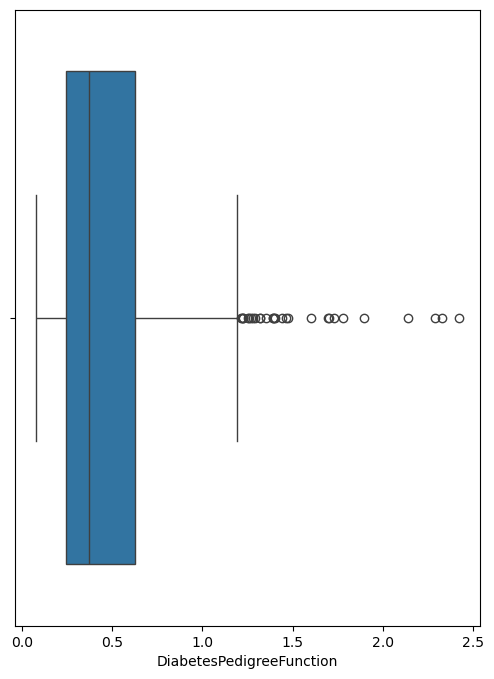

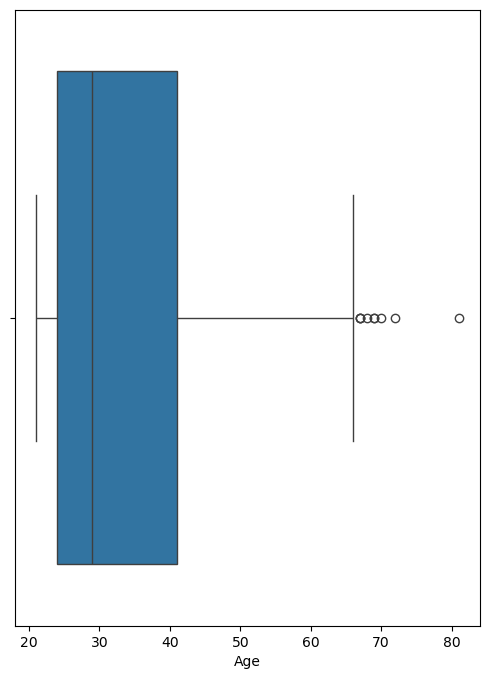

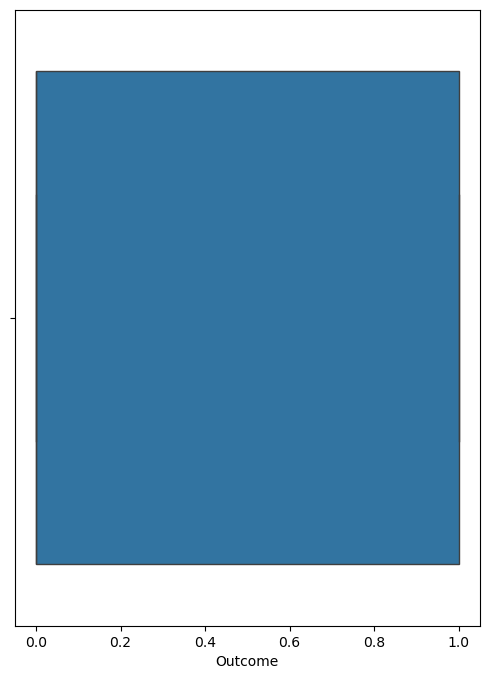

In [8]:
for col in cols:
  plt.figure(figsize=(6,8))
  sns.boxplot(x=df[col])

<Axes: >

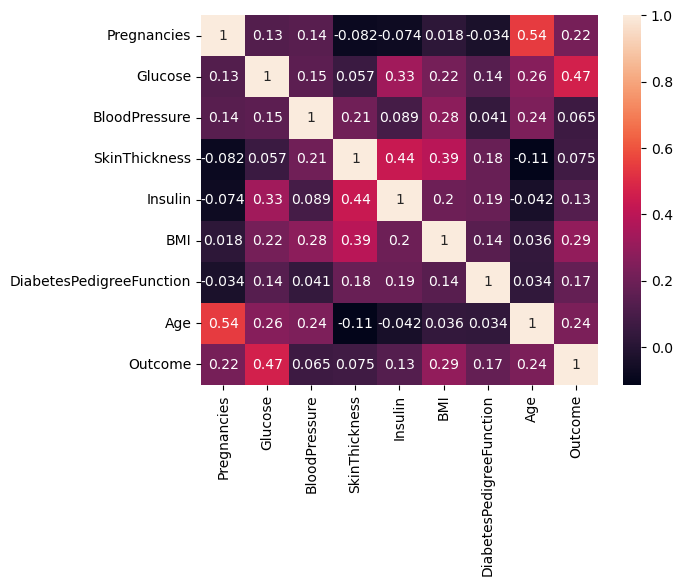

In [9]:
sns.heatmap(df.corr(),annot = True)

<Axes: xlabel='Outcome', ylabel='Glucose'>

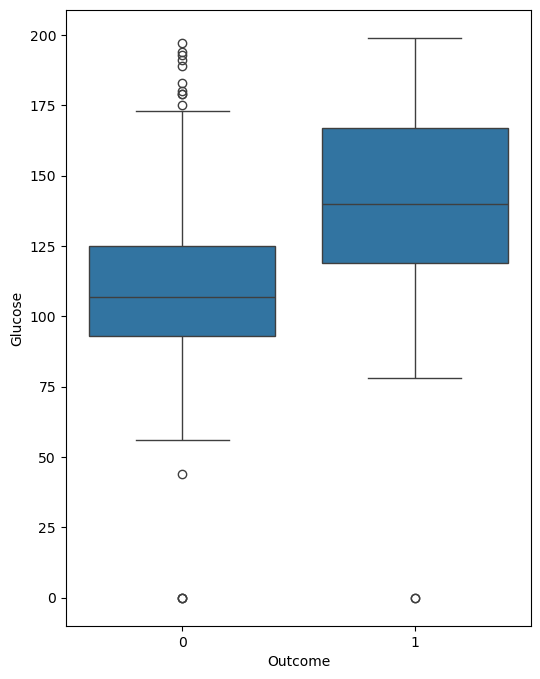

In [10]:
plt.figure(figsize=(6,8))
sns.boxplot(data=df,x='Outcome',y='Glucose')

In [40]:
med_col =['Glucose','BloodPressure','Insulin','SkinThickness','BMI']

df[med_col] = df[med_col].replace(0,pd.NA)


In [41]:
for col in med_col:
    df[col] = df[col].fillna(df[col].median())

C:\Users\sweta\AppData\Local\Temp\ipykernel_15976\267408069.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].median())
C:\Users\sweta\AppData\Local\Temp\ipykernel_15976\267408069.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].median())
C:\Users\sweta\AppData\Local\Temp\ipykernel_15976\267408069.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to

In [44]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state=42, stratify=y)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
pipeline =Pipeline([('scaler', StandardScaler()),
                    ('model',LogisticRegression(max_iter=1000))])


In [48]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [49]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("classification_report \n:", classification_report(y_test, y_pred))
print("roc_auc:", roc_auc_score(y_test, y_pred))

Accuracy : 0.7077922077922078
Precision : 0.6
Recall : 0.5
F1-score : 0.5454545454545454
classification_report 
:               precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

roc_auc: 0.66


In [51]:
cm = confusion_matrix(y_test, y_pred)
cm = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1'])
cm

,Pred 0,Pred 1
Actual 0,82,18
Actual 1,27,27


In [53]:
import os

model_dir = os.path.join(os.getcwd(), 'model')
os.makedirs(model_dir, exist_ok=True)
joblib.dump(pipeline, os.path.join(model_dir, 'diabetes_pipeline.pkl'))
print('Saved model to:', os.path.join(model_dir, 'diabetes_pipeline.pkl'))

Saved model to: c:\Users\sweta\OneDrive\Documents\Diabetes Prediction\model\diabetes_pipeline.pkl
